# Loan Approval — Clean EDA and Preprocessing

This notebook keeps the raw data unchanged during EDA. Missing values are inspected first, then imputed and encoded only after the stratified train/test split.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

sns.set_theme(style="whitegrid")

df = pd.read_csv("LoanApprovalPrediction.csv")
df = df.drop(columns=["Loan_ID"])

display(df.head())

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,Male,No,0.0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,Male,Yes,1.0,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,Male,Yes,0.0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,Male,Yes,0.0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,Male,No,0.0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [2]:
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")
print(f"Duplicate rows: {df.duplicated().sum()}")
display(df.dtypes.to_frame("dtype"))
display(df.describe(include="all").T)

Rows: 598
Columns: 12
Duplicate rows: 0


,dtype
Gender,str
Married,str
Dependents,float64
Education,str
Self_Employed,str
ApplicantIncome,int64
CoapplicantIncome,float64
LoanAmount,float64
Loan_Amount_Term,float64
Credit_History,float64


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Gender,598,2,Male,487,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Married,598,2,Yes,388,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Dependents,586.0,NaN,NaN,NaN,0.755973,1.007751,0.0,0.0,0.0,1.75,3.0
Education,598,2,Graduate,465,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Self_Employed,598,2,No,488,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ApplicantIncome,598.0,NaN,NaN,NaN,5292.252508,5807.265364,150.0,2877.5,3806.0,5746.0,81000.0
CoapplicantIncome,598.0,NaN,NaN,NaN,1631.499866,2953.315785,0.0,0.0,1211.5,2324.0,41667.0
LoanAmount,577.0,NaN,NaN,NaN,144.968804,82.704182,9.0,100.0,127.0,167.0,650.0
Loan_Amount_Term,584.0,NaN,NaN,NaN,341.917808,65.205994,12.0,360.0,360.0,360.0,480.0
Credit_History,549.0,NaN,NaN,NaN,0.843352,0.3638,0.0,1.0,1.0,1.0,1.0


## Missing values — before any encoding

In [3]:
missing_summary = (
    pd.DataFrame({
        "missing_count": df.isna().sum(),
        "missing_percent": (df.isna().mean() * 100).round(2)
    })
    .query("missing_count > 0")
    .sort_values("missing_percent", ascending=False)
)
display(missing_summary)

# Keep this raw dataframe unchanged while doing EDA.

,missing_count,missing_percent
Credit_History,49,8.19
LoanAmount,21,3.51
Loan_Amount_Term,14,2.34
Dependents,12,2.01


Loan_Status
Y    411
N    187
Name: count, dtype: int64


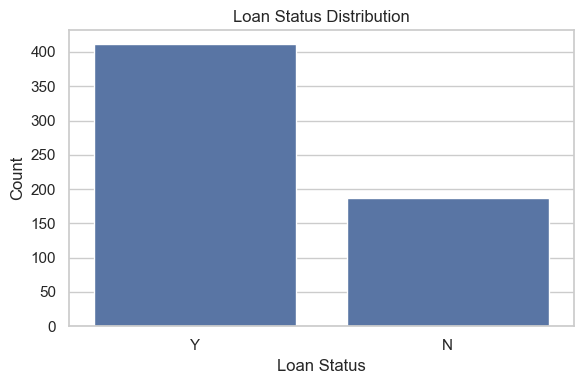

In [4]:
loan_status_counts = df["Loan_Status"].value_counts()
print(loan_status_counts)

plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="Loan_Status", order=loan_status_counts.index)
plt.title("Loan Status Distribution")
plt.xlabel("Loan Status")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig("encoder2_loan_status_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

In [5]:
# These definitions are based on the meaning of the features, not only their pandas dtype.
continuous_cols = [
    "ApplicantIncome",
    "CoapplicantIncome",
    "LoanAmount"
]

categorical_cols = [
    "Gender",
    "Married",
    "Dependents",
    "Education",
    "Self_Employed",
    "Credit_History",
    "Property_Area",
    "Loan_Amount_Term"
]

feature_cols = continuous_cols + categorical_cols
assert set(feature_cols) == set(df.drop(columns="Loan_Status").columns)
print("Continuous features:", continuous_cols)
print("Categorical/discrete features:", categorical_cols)

Continuous features: ['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount']
Categorical/discrete features: ['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'Credit_History', 'Property_Area', 'Loan_Amount_Term']


In [6]:
df=df[(df["ApplicantIncome"] <= 20000)&(df["CoapplicantIncome"] <= 10000)&(df["LoanAmount"] <= 700)]

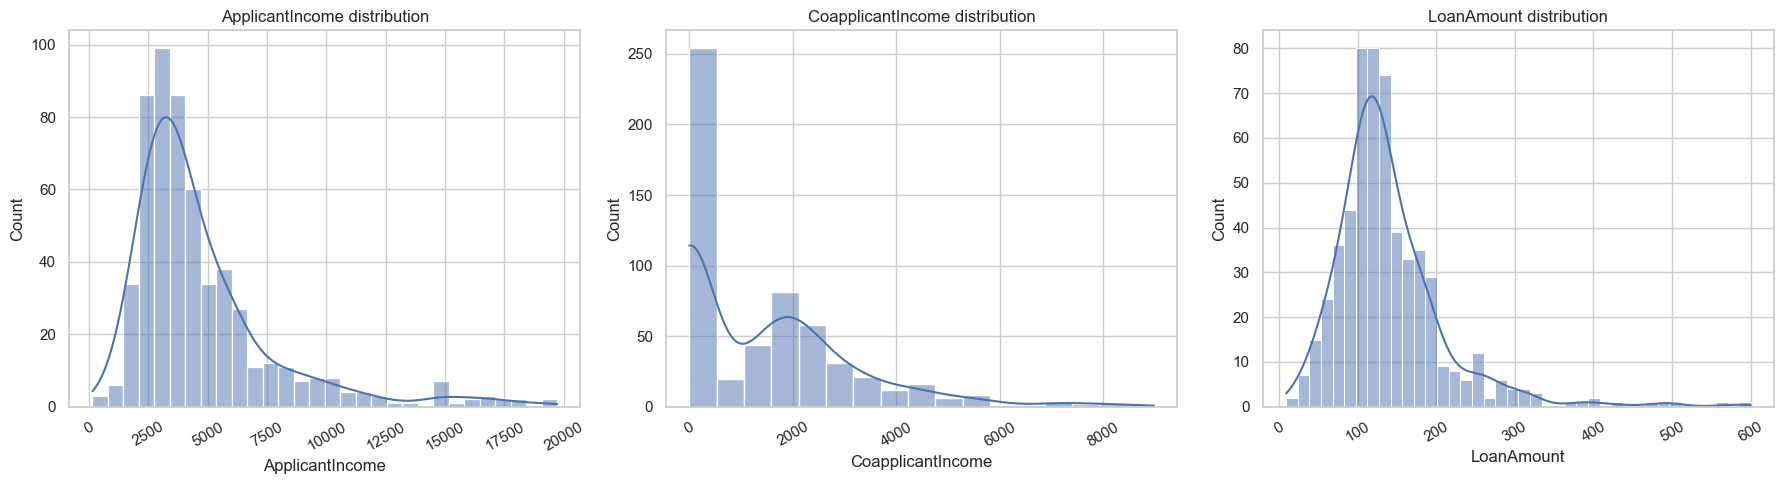

In [7]:
fig, axes = plt.subplots(1, len(continuous_cols), figsize=(18, 5))
for ax, col in zip(axes, continuous_cols):
    sns.histplot(data=df, x=col, kde=True, ax=ax)
    ax.set_title(f"{col} distribution")
    ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()

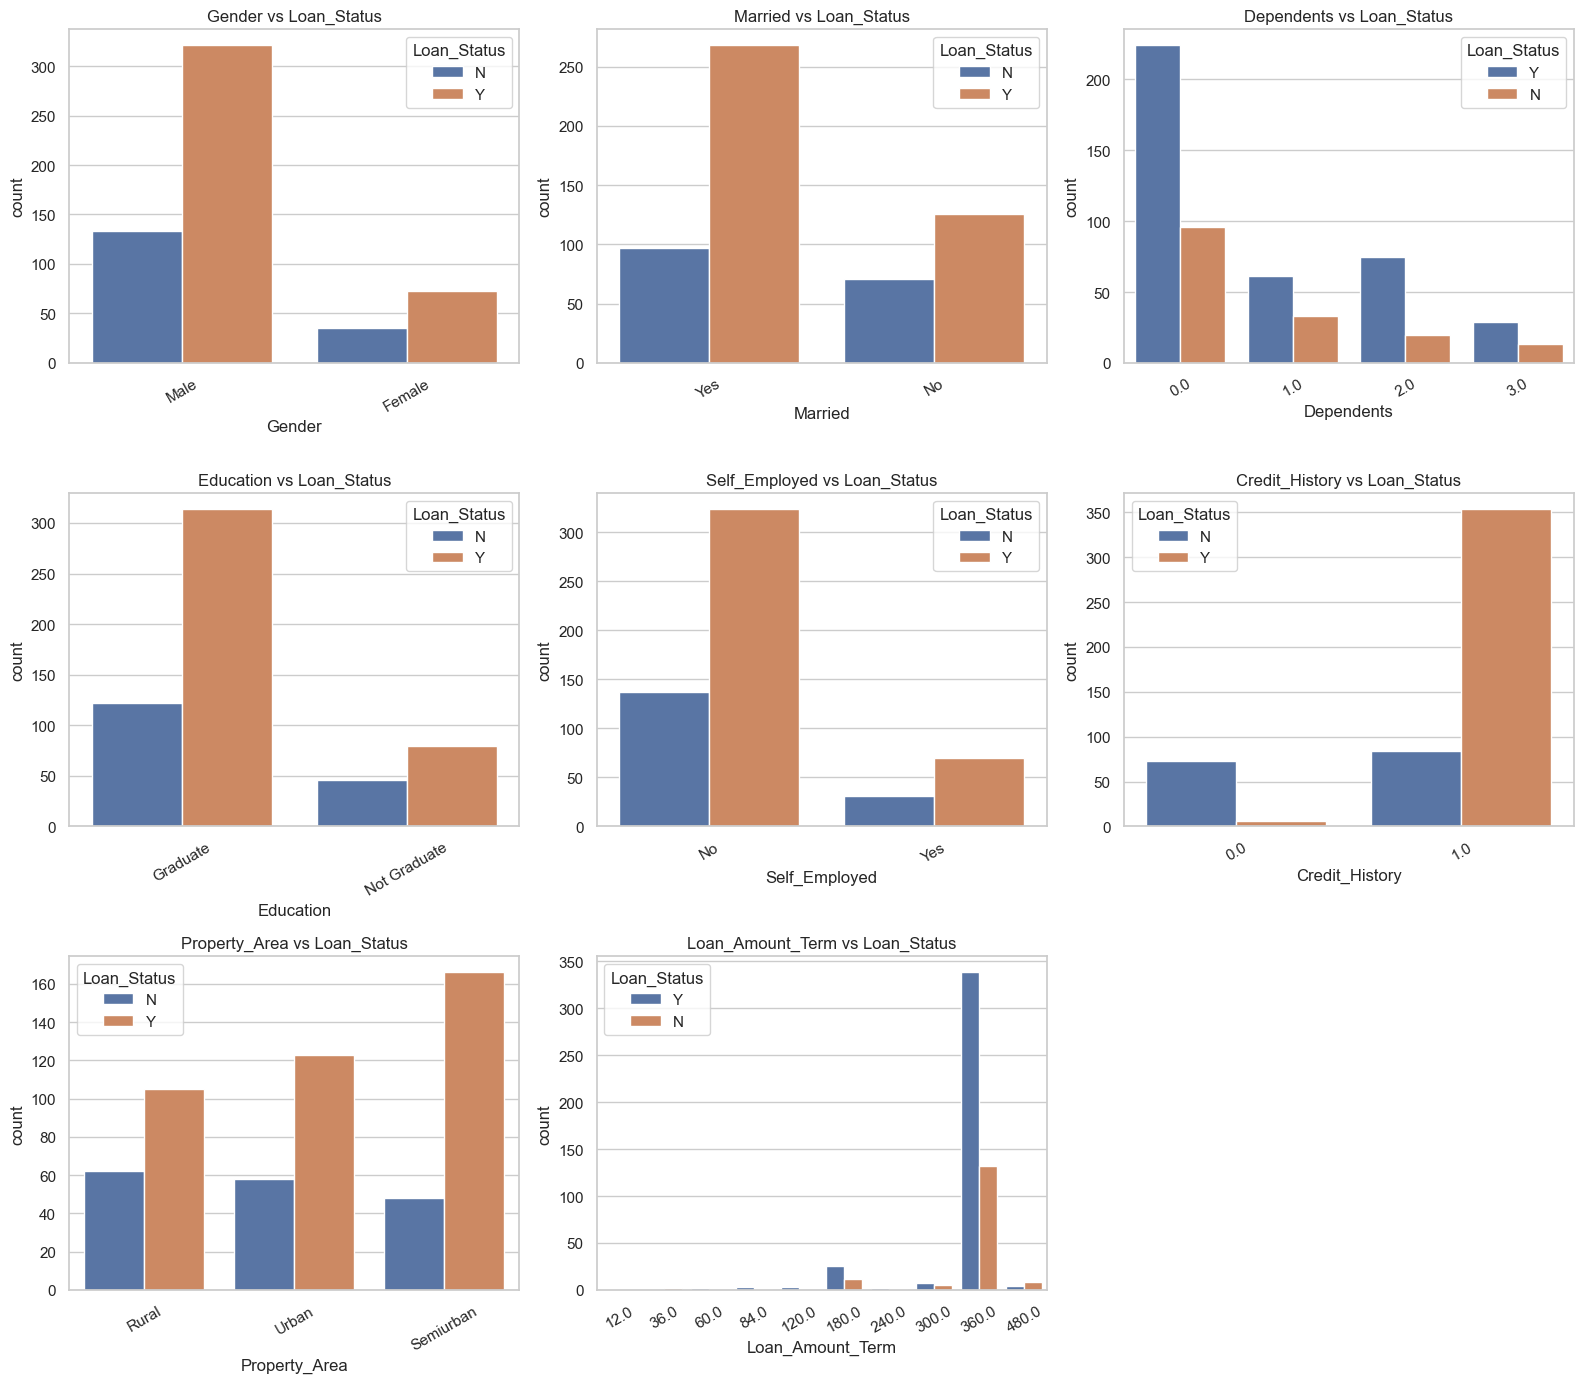

In [8]:
# Compare categorical features with the target using count plots.
fig, axes = plt.subplots(3, 3, figsize=(16, 14))
axes = axes.flatten()

for ax, col in zip(axes, categorical_cols):
    sns.countplot(data=df, x=col, hue="Loan_Status", ax=ax)
    ax.set_title(f"{col} vs Loan_Status")
    ax.tick_params(axis="x", rotation=30)

for ax in axes[len(categorical_cols):]:
    ax.remove()

plt.tight_layout()
plt.show()

,Q1,Q3,IQR,LB,UB,outlier_count
ApplicantIncome,2890.25,5674.5,2784.25,-1286.125,9850.875,40.0
CoapplicantIncome,0.00,2281.0,2281.00,-3421.500,5702.500,11.0
LoanAmount,100.00,162.0,62.00,7.000,255.000,35.0


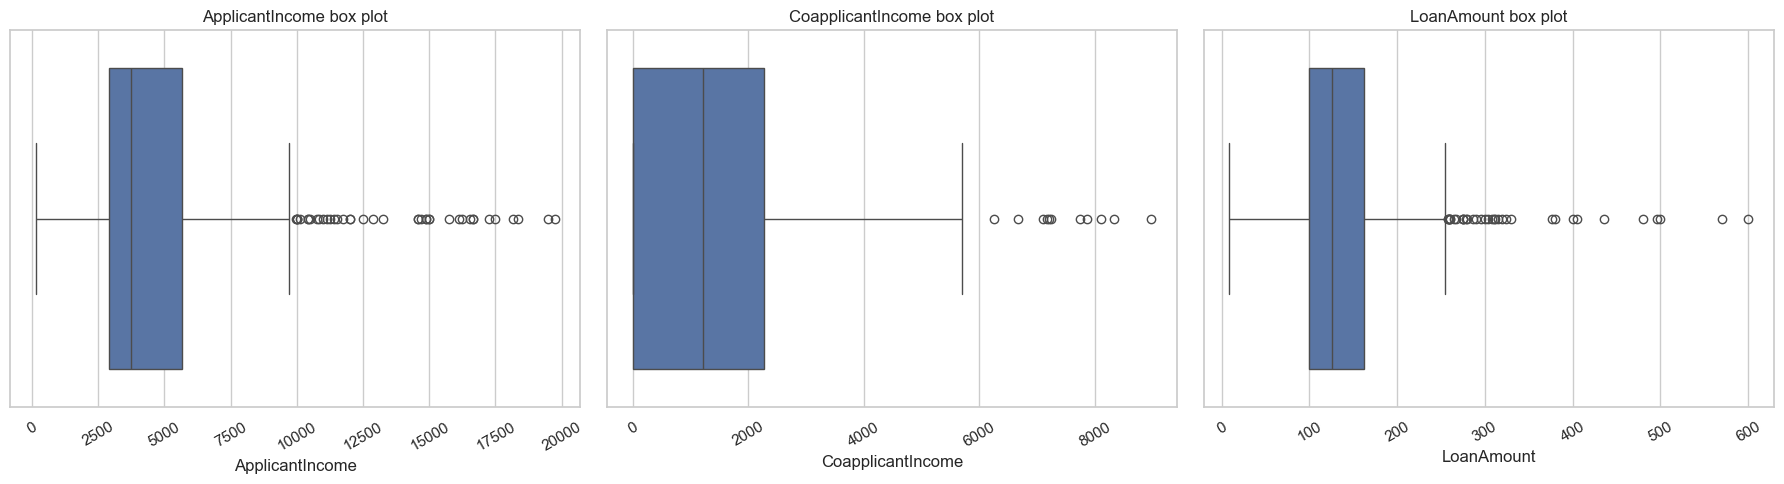

In [9]:
outlier_summary = pd.DataFrame(index=continuous_cols)
outlier_summary["Q1"] = df[continuous_cols].quantile(0.25)
outlier_summary["Q3"] = df[continuous_cols].quantile(0.75)
outlier_summary["IQR"] = outlier_summary["Q3"] - outlier_summary["Q1"]
outlier_summary["LB"] = outlier_summary["Q1"] - 1.5 * outlier_summary["IQR"]
outlier_summary["UB"] = outlier_summary["Q3"] + 1.5 * outlier_summary["IQR"]

for col in continuous_cols:
    lb = outlier_summary.loc[col, "LB"]
    ub = outlier_summary.loc[col, "UB"]
    outlier_summary.loc[col, "outlier_count"] = df[col].lt(lb).sum() + df[col].gt(ub).sum()

display(outlier_summary)

fig, axes = plt.subplots(1, len(continuous_cols), figsize=(18, 5))
for ax, col in zip(axes, continuous_cols):
    sns.boxplot(data=df, x=col, ax=ax)
    ax.set_title(f"{col} box plot")
    ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.savefig("encoder2_numerical_boxplots.png", dpi=150, bbox_inches="tight")
plt.show()

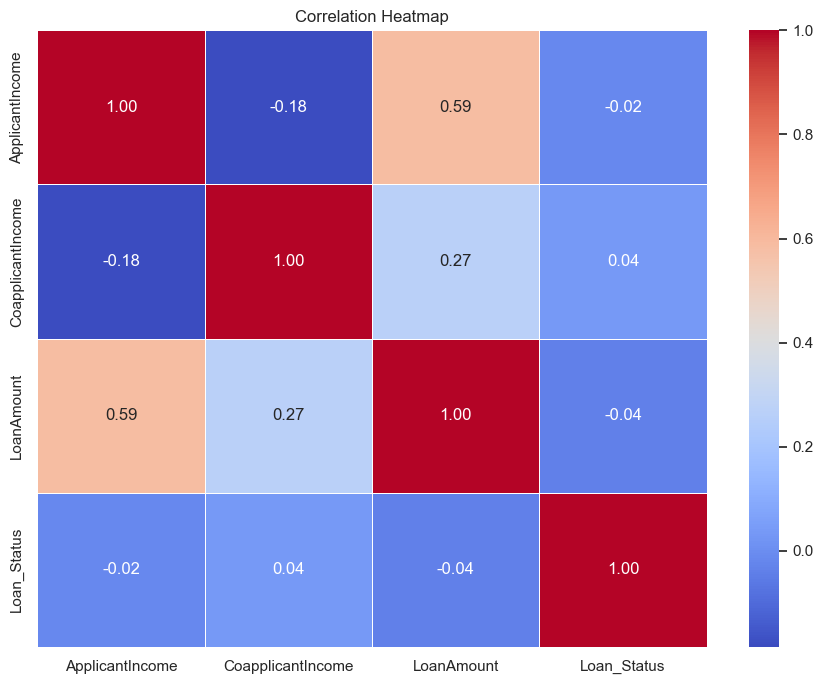

In [10]:
# Heatmap uses a temporary target copy; the raw df and its nulls are not changed.
corr_df = df[continuous_cols].copy()
corr_df["Loan_Status"] = df["Loan_Status"].map({"Y": 1, "N": 0})

plt.figure(figsize=(9, 7))
sns.heatmap(corr_df.corr(), annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.savefig("encoder2_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

Rows in df2: 538 (removed 24 rows)


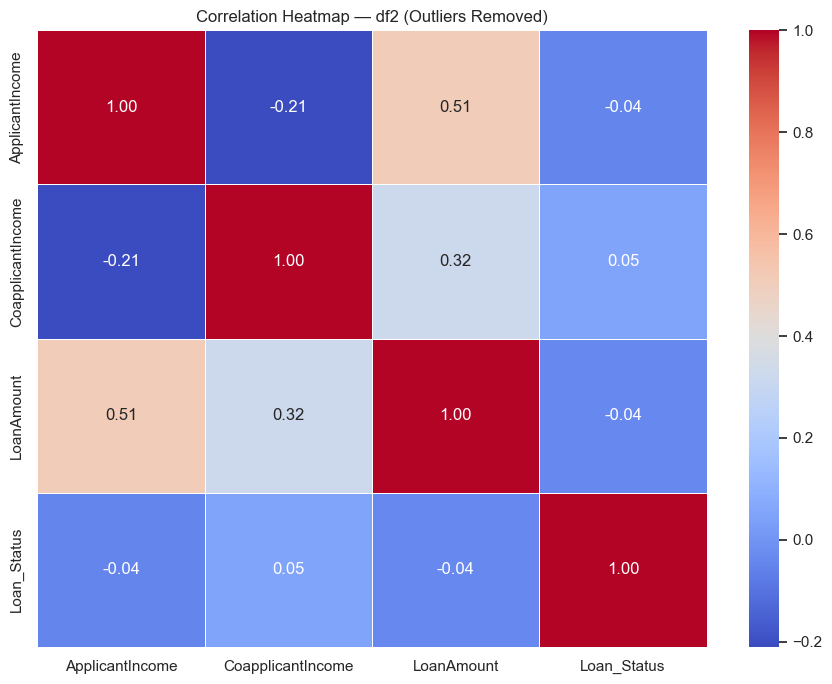

In [11]:
bounds = {}
for col in continuous_cols:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    bounds[col] = (q1 - 3 * iqr, q3 + 3 * iqr)

inlier_mask = pd.Series(True, index=df.index)
for col, (lower, upper) in bounds.items():
    inlier_mask &= df[col].between(lower, upper) | df[col].isna()

df2 = df.loc[inlier_mask].copy()
print(f"Rows in df2: {len(df2)} (removed {len(df) - len(df2)} rows)")

corr_df2 = df2[continuous_cols].copy()
corr_df2["Loan_Status"] = df2["Loan_Status"].map({"Y": 1, "N": 0})

plt.figure(figsize=(9, 7))
sns.heatmap(corr_df2.corr(), annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap — df2 (Outliers Removed)")
plt.tight_layout()
plt.show()

,Q1,Q3,IQR,LB,UB,outlier_count
ApplicantIncome,2890.25,5674.5,2784.25,-5462.5,14027.25,19.0
CoapplicantIncome,0.00,2281.0,2281.00,-6843.0,9124.00,0.0
LoanAmount,100.00,162.0,62.00,-86.0,348.00,10.0


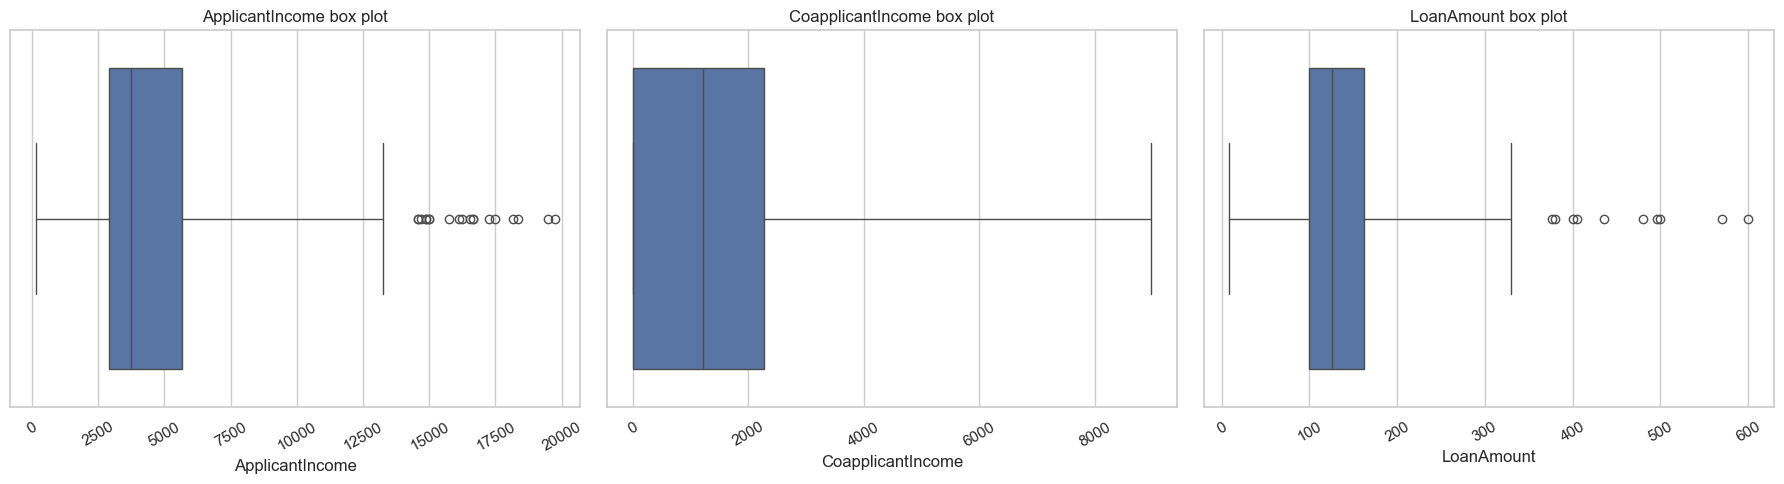

In [12]:
outlier_summary = pd.DataFrame(index=continuous_cols)
outlier_summary["Q1"] = df[continuous_cols].quantile(0.25)
outlier_summary["Q3"] = df[continuous_cols].quantile(0.75)
outlier_summary["IQR"] = outlier_summary["Q3"] - outlier_summary["Q1"]
outlier_summary["LB"] = outlier_summary["Q1"] - 3 * outlier_summary["IQR"]
outlier_summary["UB"] = outlier_summary["Q3"] + 3 * outlier_summary["IQR"]

for col in continuous_cols:
    lb = outlier_summary.loc[col, "LB"]
    ub = outlier_summary.loc[col, "UB"]
    outlier_summary.loc[col, "outlier_count"] = df[col].lt(lb).sum() + df[col].gt(ub).sum()

display(outlier_summary)

fig, axes = plt.subplots(1, len(continuous_cols), figsize=(18, 5))
for ax, col in zip(axes, continuous_cols):
    sns.boxplot(data=df, x=col, ax=ax,whis=3)
    ax.set_title(f"{col} box plot")
    ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.savefig("encoder2_numerical_boxplots_2.png", dpi=150, bbox_inches="tight")
plt.show()

## Split first, then impute, encode, and scale

In [13]:
X = df.drop(columns="Loan_Status").copy()
# Keep categorical values as strings while preserving their missing values.
X[categorical_cols] = X[categorical_cols].astype("string")
y = df["Loan_Status"].map({"Y": 1, "N": 0})

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("Nulls in X_train before preprocessing:")
display(X_train.isna().sum()[lambda s: s > 0])

X_train shape: (449, 11)
X_test shape: (113, 11)
Nulls in X_train before preprocessing:


Dependents          11
Loan_Amount_Term    13
Credit_History      37
dtype: int64

In [14]:
X_train_null = X_train[X_train.isnull().any(axis=1)]
X_train_null

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area
581,Male,No,<NA>,Graduate,No,2987,0.0,88.0,360.0,0.0,Semiurban
123,Female,No,0.0,Graduate,No,3692,0.0,93.0,360.0,<NA>,Rural
273,Female,Yes,0.0,Not Graduate,No,4100,0.0,124.0,360.0,<NA>,Rural
478,Male,No,0.0,Not Graduate,No,2699,2785.0,96.0,360.0,<NA>,Semiurban
110,Male,Yes,0.0,Not Graduate,No,3572,4114.0,152.0,<NA>,0.0,Rural
338,Male,Yes,<NA>,Not Graduate,No,3523,3230.0,152.0,360.0,0.0,Rural
485,Male,Yes,0.0,Graduate,No,4625,2857.0,111.0,12.0,<NA>,Urban
327,Male,Yes,<NA>,Graduate,Yes,5503,4490.0,70.0,<NA>,1.0,Semiurban
23,Male,Yes,1.0,Graduate,Yes,3717,2925.0,151.0,360.0,<NA>,Semiurban
19,Male,Yes,0.0,Graduate,Yes,2600,3500.0,115.0,<NA>,1.0,Urban


In [15]:
X_train_not_null = X_train[~X_train.isnull().any(axis=1)]

In [16]:
X_train_null.shape

(60, 11)

In [17]:
X_test_null = X_test[X_test.isnull().any(axis=1)]
X_test_null

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area
435,Male,Yes,0.0,Graduate,No,7333,8333.0,175.0,300.0,<NA>,Rural
355,Male,Yes,0.0,Graduate,No,3013,3033.0,95.0,300.0,<NA>,Urban
384,Male,Yes,0.0,Graduate,No,2583,2115.0,120.0,360.0,<NA>,Urban
310,Male,Yes,0.0,Graduate,No,2058,2134.0,88.0,360.0,<NA>,Urban
479,Male,Yes,1.0,Not Graduate,No,5333,1131.0,186.0,360.0,<NA>,Urban
126,Male,Yes,0.0,Graduate,No,6080,2569.0,182.0,360.0,<NA>,Rural
340,Male,Yes,0.0,Graduate,No,6333,4583.0,259.0,360.0,<NA>,Semiurban
254,Male,Yes,1.0,Graduate,No,6083,4250.0,330.0,360.0,<NA>,Urban
359,Male,No,0.0,Graduate,No,5124,0.0,124.0,<NA>,0.0,Rural


In [18]:
X_test_not_null = X_test[~X_test.isnull().any(axis=1)]

In [19]:
from sklearn.neighbors import NearestNeighbors

null_counts = X_train.isna().sum().sort_values(ascending=False)
knn_impute_cols = null_counts[null_counts.gt(0)].head(3).index.tolist()
print("Features imputed with KNN mode:", knn_impute_cols)

distance_numeric_cols = [col for col in continuous_cols if col in X_train.columns]
distance_categorical_cols = [col for col in categorical_cols if col in X_train.columns]
distance_cols = distance_numeric_cols + distance_categorical_cols

def make_dense_ohe():
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)

def knn_mode_impute(target_df, missing_df, reference_df, impute_cols, k=3):
    '''Fill missing values with the mode of the k nearest complete rows.'''
    result = target_df.copy()
    if missing_df.empty or reference_df.empty:
        return result

    distance_preprocessor = ColumnTransformer(
        transformers=[
            ("num", Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler())
            ]), distance_numeric_cols),
            ("cat", Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("onehot", make_dense_ohe())
            ]), distance_categorical_cols)
        ],
        remainder="drop"
    )

    reference_for_distance = reference_df[distance_cols].astype(object).where(reference_df[distance_cols].notna(), np.nan)
    query_for_distance = missing_df[distance_cols].astype(object).where(missing_df[distance_cols].notna(), np.nan)
    reference_matrix = distance_preprocessor.fit_transform(reference_for_distance)
    query_matrix = distance_preprocessor.transform(query_for_distance)
    n_neighbors = min(k, len(reference_df))
    knn = NearestNeighbors(n_neighbors=n_neighbors, metric="euclidean")
    knn.fit(reference_matrix)
    _, neighbor_positions = knn.kneighbors(query_matrix)

    for row_number, row_index in enumerate(missing_df.index):
        neighbor_rows = reference_df.iloc[neighbor_positions[row_number]]
        for col in impute_cols:
            if pd.isna(result.at[row_index, col]):
                neighbor_mode = neighbor_rows[col].mode(dropna=True)
                fallback_mode = reference_df[col].mode(dropna=True)
                value = neighbor_mode.iloc[0] if not neighbor_mode.empty else fallback_mode.iloc[0]
                result.at[row_index, col] = value
    return result

X_train_knn = knn_mode_impute(
    X_train, X_train_null, X_train_not_null, knn_impute_cols, k=3
)

X_test_knn = knn_mode_impute(
    X_test, X_test_null, X_train_not_null, knn_impute_cols, k=3
)

for col in X_train_knn.columns:
    train_mode = X_train_not_null[col].mode(dropna=True)
    if not train_mode.empty:
        X_train_knn[col] = X_train_knn[col].fillna(train_mode.iloc[0])
        X_test_knn[col] = X_test_knn[col].fillna(train_mode.iloc[0])

print("Remaining nulls in X_train_knn:")
display(X_train_knn.isna().sum()[lambda s: s > 0])
print("Remaining nulls in X_test_knn:")
display(X_test_knn.isna().sum()[lambda s: s > 0])

Features imputed with KNN mode: ['Credit_History', 'Loan_Amount_Term', 'Dependents']
Remaining nulls in X_train_knn:


Series([], dtype: int64)

Remaining nulls in X_test_knn:


Series([], dtype: int64)

In [20]:
education_map = {"Not Graduate": 0, "Graduate": 1}
ohe_cols = [col for col in categorical_cols if col != "Education"]

X_train_encoded_base = X_train_knn.copy()
X_test_encoded_base = X_test_knn.copy()
X_train_encoded_base["Education"] = X_train_encoded_base["Education"].map(education_map).astype("int64")
X_test_encoded_base["Education"] = X_test_encoded_base["Education"].map(education_map).astype("int64")

ohe_encoder = make_dense_ohe()
train_ohe = ohe_encoder.fit_transform(X_train_encoded_base[ohe_cols])
test_ohe = ohe_encoder.transform(X_test_encoded_base[ohe_cols])
ohe_feature_names = ohe_encoder.get_feature_names_out(ohe_cols)

X_train_encoded = pd.concat([
    X_train_encoded_base[continuous_cols + ["Education"]],
    pd.DataFrame(train_ohe, index=X_train_encoded_base.index, columns=ohe_feature_names)
], axis=1)
X_test_encoded = pd.concat([
    X_test_encoded_base[continuous_cols + ["Education"]],
    pd.DataFrame(test_ohe, index=X_test_encoded_base.index, columns=ohe_feature_names)
], axis=1)

print("Encoded train shape:", X_train_encoded.shape)
display(X_train_encoded.head())

Encoded train shape: (449, 29)


,ApplicantIncome,CoapplicantIncome,LoanAmount,Education,Gender_Female,Gender_Male,Married_No,Married_Yes,Dependents_0.0,Dependents_1.0,...,Loan_Amount_Term_12.0,Loan_Amount_Term_120.0,Loan_Amount_Term_180.0,Loan_Amount_Term_240.0,Loan_Amount_Term_300.0,Loan_Amount_Term_36.0,Loan_Amount_Term_360.0,Loan_Amount_Term_480.0,Loan_Amount_Term_60.0,Loan_Amount_Term_84.0
292,5000,2541.0,151.0,1,1.0,0.0,1.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
595,8072,240.0,253.0,1,0.0,1.0,0.0,1.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
407,2995,0.0,60.0,1,1.0,0.0,1.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
182,2178,0.0,66.0,1,0.0,1.0,0.0,1.0,0.0,1.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
402,3867,0.0,62.0,0,1.0,0.0,1.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0


In [21]:
from sklearn.preprocessing import RobustScaler

scaled_numeric_cols = continuous_cols + ["Education"]
robust_scaler = RobustScaler()

X_train_scaled = X_train_encoded.copy()
X_test_scaled = X_test_encoded.copy()
X_train_scaled[scaled_numeric_cols] = robust_scaler.fit_transform(X_train_encoded[scaled_numeric_cols])
X_test_scaled[scaled_numeric_cols] = robust_scaler.transform(X_test_encoded[scaled_numeric_cols])

X_train_final = X_train_scaled
X_test_final = X_test_scaled

print("Final train shape:", X_train_final.shape)
print("Final test shape:", X_test_final.shape)
display(X_train_final.head())

Final train shape: (449, 29)
Final test shape: (113, 29)


,ApplicantIncome,CoapplicantIncome,LoanAmount,Education,Gender_Female,Gender_Male,Married_No,Married_Yes,Dependents_0.0,Dependents_1.0,...,Loan_Amount_Term_12.0,Loan_Amount_Term_120.0,Loan_Amount_Term_180.0,Loan_Amount_Term_240.0,Loan_Amount_Term_300.0,Loan_Amount_Term_36.0,Loan_Amount_Term_360.0,Loan_Amount_Term_480.0,Loan_Amount_Term_60.0,Loan_Amount_Term_84.0
292,0.480899,0.628889,0.433333,0.0,1.0,0.0,1.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
595,1.631461,-0.393778,2.133333,0.0,0.0,1.0,0.0,1.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
407,-0.270037,-0.500444,-1.083333,0.0,1.0,0.0,1.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
182,-0.576030,-0.500444,-0.983333,0.0,0.0,1.0,0.0,1.0,0.0,1.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
402,0.056554,-0.500444,-1.050000,-1.0,1.0,0.0,1.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0


In [22]:
from sklearn.ensemble import VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report

voting_model = VotingClassifier(
    estimators=[
        ("logistic", LogisticRegression(max_iter=1000, random_state=42)),
        ("svm", SVC(probability=True, random_state=42)),
        ("decision_tree", DecisionTreeClassifier(max_depth=5,random_state=42)),
        ("knn", KNeighborsClassifier(n_neighbors=3))
    ],
    voting="soft"
)

voting_model.fit(X_train_final, y_train)

y_pred = voting_model.predict(X_test_final)

print("Test accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Test accuracy: 0.8495575221238938
              precision    recall  f1-score   support

           0       0.95      0.53      0.68        34
           1       0.83      0.99      0.90        79

    accuracy                           0.85       113
   macro avg       0.89      0.76      0.79       113
weighted avg       0.87      0.85      0.83       113



In [ ]:
from sklearn.ensemble import RandomForestClassifier

random_forest_model = RandomForestClassifier(
    n_estimators=300,
    max_features="sqrt",  # اختيار عشوائي للخصائص عند كل split
    bootstrap=True,       # عينات bootstrap لكل شجرة من بيانات التدريب
    oob_score=True,
    random_state=42,
    n_jobs=-1
)

random_forest_model.fit(X_train_final, y_train)

rf_y_pred = random_forest_model.predict(X_test_final)

print("Test accuracy:", accuracy_score(y_test, rf_y_pred))
print("Out-of-bag score:", random_forest_model.oob_score_)
print(classification_report(y_test, rf_y_pred))

# عرض أهم 15 خاصية
rf_importance = (
    pd.Series(random_forest_model.feature_importances_, index=X_train_final.columns)
    .sort_values(ascending=False)
    .head(15)
)

rf_importance.sort_values().plot(kind="barh", figsize=(8, 6))
plt.title("Top 15 Random Forest Feature Importances")
plt.xlabel("Feature importance")
plt.tight_layout()
plt.show()